# Grounded SAM 2 — Video Tracking Mode

Instead of running Grounding DINO on every image independently, this notebook:

1. **Scans the first few frames** with Grounding DINO to find the first frame where hands appear.
2. **Initialises SAM 2 video predictor** on that frame with the detected hand boxes.
3. **Propagates forward (and backward)** through all frames automatically — no detection needed on every frame.

This gives much more **consistent, temporally smooth masks** and avoids false positives on frames where the hand is partially occluded.

## 1 — Check GPU

In [1]:
!pip install -q "transformers==4.40.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 53.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [2]:
import torch
assert torch.cuda.is_available(), "No GPU — go to Runtime > Change runtime type > GPU"
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

GPU : Tesla T4
CUDA: 12.8
VRAM: 15.6 GB


## 2 — Clone & Install

> ⏱ Takes ~5 min the first time (Grounding DINO compiles a CUDA op).

In [3]:
import os

if not os.path.isdir("/content/Grounded-SAM-2"):
    !git clone --depth 1 https://github.com/IDEA-Research/Grounded-SAM-2 /content/Grounded-SAM-2

%cd /content/Grounded-SAM-2

os.environ["CUDA_HOME"] = "/usr/local/cuda"

!pip install -e . -q
!pip install --no-build-isolation -e grounding_dino -q
!pip install supervision -q

print("\n✅ Done")

/content/Grounded-SAM-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done

✅ Done


## 3 — Download Checkpoints

In [4]:
import os

# ── SAM 2.1 checkpoint ───────────────────────────────────────────────────────
# Options: tiny (~40MB), small (~90MB), base_plus (~300MB), large (~900MB)
SAM2_CKPT_NAME = "sam2.1_hiera_large.pt"       # best accuracy
SAM2_CFG_NAME  = "configs/sam2.1/sam2.1_hiera_l.yaml"
SAM2_CKPT_PATH = f"/content/Grounded-SAM-2/checkpoints/{SAM2_CKPT_NAME}"

if not os.path.exists(SAM2_CKPT_PATH):
    url = f"https://dl.fbaipublicfiles.com/segment_anything_2/092824/{SAM2_CKPT_NAME}"
    !wget -q --show-progress -O "{SAM2_CKPT_PATH}" "{url}"

# ── Grounding DINO checkpoint ────────────────────────────────────────────────
GDINO_CKPT_PATH = "/content/Grounded-SAM-2/gdino_checkpoints/groundingdino_swint_ogc.pth"
if not os.path.exists(GDINO_CKPT_PATH):
    %cd /content/Grounded-SAM-2/gdino_checkpoints
    !bash download_ckpts.sh
    %cd /content/Grounded-SAM-2

print("✅ Checkpoints ready")

✅ Checkpoints ready


In [5]:
!pip install -q addict yapf timm


## 4 — Load Models

In [6]:
import sys, os
sys.path.insert(0, "/content/Grounded-SAM-2")
sys.path.insert(0, "/content/Grounded-SAM-2/grounding_dino")

import torch
import numpy as np
import cv2
import shutil
import glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# SAM 2 VIDEO predictor (replaces SAM2ImagePredictor)
from sam2.build_sam import build_sam2_video_predictor

# Grounding DINO (local compiled version — needed for video pipeline)
from grounding_dino.groundingdino.util.inference import load_model, load_image, predict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# ── Grounding DINO ────────────────────────────────────────────────────────────
GDINO_CFG  = "/content/Grounded-SAM-2/grounding_dino/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GDINO_CKPT = "/content/Grounded-SAM-2/gdino_checkpoints/groundingdino_swint_ogc.pth"

print("Loading Grounding DINO...")
gdino_model = load_model(GDINO_CFG, GDINO_CKPT, device=DEVICE)
print("✅ Grounding DINO loaded")

# ── SAM 2 video predictor ─────────────────────────────────────────────────────
print("\nLoading SAM 2 video predictor...")
video_predictor = build_sam2_video_predictor(
    SAM2_CFG_NAME, SAM2_CKPT_PATH, device=DEVICE
)
print("✅ SAM 2 video predictor loaded")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Loading Grounding DINO...
final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


✅ Grounding DINO loaded

Loading SAM 2 video predictor...


✅ SAM 2 video predictor loaded


## 5 — Mount Drive & Unzip Images

In [40]:
from google.colab import drive
drive.mount("/content/drive")

!unzip -q -o "/content/drive/MyDrive/novel2.zip" -d "/content/novel2" -x "__MACOSX/*" "*.DS_Store"
print("Unzipped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
caution: excluded filename not matched:  *.DS_Store
Unzipped.


In [41]:
import os
# List everything directly under /content to see what folders exist
print(os.listdir("/content"))

['.config', 'frames_numbered', 'Grounded-SAM-2', 'drive', 'seg_results', 'novel2', 'novel', 'sample_data']


## 6 — Configure

Only change `IMAGE_FOLDER`, `TEXT_PROMPT`, and the thresholds.

In [42]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
IMAGE_FOLDER  = "/content/novel2/novel"   # folder with your .jpg frames
TEXT_PROMPT   = "hand."                  # Grounding DINO prompt — lowercase + dot
OUTPUT_FOLDER = "/content/seg_results"

BOX_THRESHOLD  = 0.70
TEXT_THRESHOLD = 0.25

# How many frames to scan at the start looking for the first hand detection.
# Increase if hands don't appear until later in your sequence.
MAX_SCAN_FRAMES = 1000
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

image_paths = sorted(
    glob.glob(os.path.join(IMAGE_FOLDER, "*.jpg")) +
    glob.glob(os.path.join(IMAGE_FOLDER, "*.jpeg")) +
    glob.glob(os.path.join(IMAGE_FOLDER, "*.png"))
)
print(f"Found {len(image_paths)} frames in {IMAGE_FOLDER}")
print(f"First frame: {os.path.basename(image_paths[0])}")
print(f"Last frame : {os.path.basename(image_paths[-1])}")

Found 144 frames in /content/novel2/novel
First frame: 000000_novel00.jpg
Last frame : 000115_novel05.jpg


In [49]:
import shutil
shutil.rmtree("/content/frames_numbered", ignore_errors=True)

## 7 — Prepare Frames for SAM 2 Video Predictor

SAM 2's video predictor expects frames named as plain integers (`0.jpg`, `1.jpg`, …).  
This cell copies your frames into a temp folder with those names.

In [50]:
FRAMES_DIR = "/content/frames_numbered"
os.makedirs(FRAMES_DIR, exist_ok=True)

# Map: integer index → original filename stem (for saving results later)
idx_to_stem = {}

for i, src in enumerate(image_paths):
    dst = os.path.join(FRAMES_DIR, f"{i}.jpg")
    if not os.path.exists(dst):
        img = cv2.imread(src)
        cv2.imwrite(dst, img, [cv2.IMWRITE_JPEG_QUALITY, 95])
    idx_to_stem[i] = os.path.splitext(os.path.basename(src))[0]

print(f"✅ {len(image_paths)} frames prepared in {FRAMES_DIR}")

✅ 144 frames prepared in /content/frames_numbered


## 8 — Find First Frame with Hands (Grounding DINO)

Grounding DINO runs on at most `MAX_SCAN_FRAMES` frames — just enough to find  
where hands first appear. SAM 2 takes it from there for the rest of the video.

In [51]:
first_frame_idx = None
first_boxes     = None

for scan_idx in range(min(MAX_SCAN_FRAMES, len(image_paths))):
    frame_path = os.path.join(FRAMES_DIR, f"{scan_idx}.jpg")

    # load_image returns (PIL image, transformed tensor) for Grounding DINO
    image_source, image_tensor = load_image(frame_path)

    boxes, confidences, labels = predict(
        model=gdino_model,
        image=image_tensor,
        caption=TEXT_PROMPT,
        box_threshold=BOX_THRESHOLD,
        text_threshold=TEXT_THRESHOLD,
        device=DEVICE,
    )

    if len(boxes) > 0:
        # Grounding DINO returns boxes in [cx, cy, w, h] normalised format
        # Convert to absolute xyxy for SAM 2
        H, W = image_source.shape[:2]
        boxes_xyxy = boxes.clone()
        boxes_xyxy[:, 0] = (boxes[:, 0] - boxes[:, 2] / 2) * W   # x1
        boxes_xyxy[:, 1] = (boxes[:, 1] - boxes[:, 3] / 2) * H   # y1
        boxes_xyxy[:, 2] = (boxes[:, 0] + boxes[:, 2] / 2) * W   # x2
        boxes_xyxy[:, 3] = (boxes[:, 1] + boxes[:, 3] / 2) * H   # y2

        first_frame_idx = scan_idx
        first_boxes     = boxes_xyxy.cpu().numpy()

        print(f"✅ Hands found in frame {scan_idx} ({idx_to_stem[scan_idx]})")
        print(f"   {len(first_boxes)} detection(s): {labels}  scores: {[f'{c:.2f}' for c in confidences.tolist()]}")
        break
    else:
        print(f"   Frame {scan_idx}: no hands detected")

if first_frame_idx is None:
    raise RuntimeError(
        f"No hands found in the first {MAX_SCAN_FRAMES} frames. "
        "Try lowering BOX_THRESHOLD or increasing MAX_SCAN_FRAMES."
    )

   Frame 0: no hands detected
   Frame 1: no hands detected
   Frame 2: no hands detected
   Frame 3: no hands detected
   Frame 4: no hands detected
   Frame 5: no hands detected
   Frame 6: no hands detected
   Frame 7: no hands detected
   Frame 8: no hands detected
   Frame 9: no hands detected
   Frame 10: no hands detected
   Frame 11: no hands detected
   Frame 12: no hands detected
   Frame 13: no hands detected
   Frame 14: no hands detected
   Frame 15: no hands detected
   Frame 16: no hands detected
   Frame 17: no hands detected
   Frame 18: no hands detected
   Frame 19: no hands detected
   Frame 20: no hands detected
   Frame 21: no hands detected
   Frame 22: no hands detected
   Frame 23: no hands detected
   Frame 24: no hands detected
   Frame 25: no hands detected
   Frame 26: no hands detected
   Frame 27: no hands detected
   Frame 28: no hands detected
   Frame 29: no hands detected
   Frame 30: no hands detected
   Frame 31: no hands detected
   Frame 32: no ha

## 9 — Initialise SAM 2 Video Predictor & Propagate

SAM 2 is given the hand bounding boxes on the first detected frame,  
then tracks those objects **forward and backward** through the entire sequence automatically.

In [52]:
# ── Init video state ──────────────────────────────────────────────────────────
# offload_video_to_cpu=True keeps frames in RAM not VRAM (safer on T4)
inference_state = video_predictor.init_state(
    video_path=FRAMES_DIR,
    offload_video_to_cpu=True,
    offload_state_to_cpu=False,
)
video_predictor.reset_state(inference_state)

# ── Add hand boxes as prompts on the first detected frame ─────────────────────
# Each detected box becomes a separately tracked object (obj_id 1, 2, ...)
for obj_id, box in enumerate(first_boxes, start=1):
    _, out_obj_ids, out_mask_logits = video_predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=first_frame_idx,
        obj_id=obj_id,
        box=box,
    )
print(f"✅ Initialised {len(first_boxes)} tracked object(s) on frame {first_frame_idx}")

# ── Propagate FORWARD through all frames ──────────────────────────────────────
frame_masks = {}   # frame_idx → combined bool mask (H, W)

print("\nPropagating forward...")
with torch.autocast(DEVICE, dtype=torch.bfloat16):
    for frame_idx, obj_ids, mask_logits in video_predictor.propagate_in_video(
        inference_state,
        start_frame_idx=first_frame_idx,
        reverse=False,
    ):
        # mask_logits: (N_obj, 1, H, W) — threshold at 0 to get binary mask
        masks = (mask_logits > 0.0).squeeze(1).cpu().numpy()   # (N_obj, H, W)
        frame_masks[frame_idx] = masks.any(axis=0)             # union of all hands
        if (frame_idx + 1) % 20 == 0 or frame_idx == len(image_paths) - 1:
            print(f"  forward: frame {frame_idx+1}/{len(image_paths)}")

# ── Propagate BACKWARD (covers frames before the first detection) ─────────────
if first_frame_idx > 0:
    print("\nPropagating backward...")
    with torch.autocast(DEVICE, dtype=torch.bfloat16):
        for frame_idx, obj_ids, mask_logits in video_predictor.propagate_in_video(
            inference_state,
            start_frame_idx=first_frame_idx,
            reverse=True,
        ):
            masks = (mask_logits > 0.0).squeeze(1).cpu().numpy()
            frame_masks[frame_idx] = masks.any(axis=0)
            if (first_frame_idx - frame_idx) % 20 == 0:
                print(f"  backward: frame {frame_idx}")

print(f"\n✅ Propagation done — masks collected for {len(frame_masks)} frames")

frame loading (JPEG): 100%|██████████| 144/144 [00:04<00:00, 29.03it/s]


✅ Initialised 1 tracked object(s) on frame 36

Propagating forward...


propagate in video:   4%|▎         | 4/108 [00:03<01:36,  1.08it/s]

  forward: frame 40/144


propagate in video:  22%|██▏       | 24/108 [00:29<01:48,  1.30s/it]

...

  backward: frame 36


propagate in video:  57%|█████▋    | 21/37 [00:25<00:20,  1.29s/it]

  backward: frame 16


propagate in video: 100%|██████████| 37/37 [00:46<00:00,  1.25s/it]


✅ Propagation done — masks collected for 144 frames


## 10 — Save Masks + Visualisations

In [53]:
MASK_DIR = os.path.join(OUTPUT_FOLDER, "masks")
VIZ_DIR  = os.path.join(OUTPUT_FOLDER, "viz")
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,  exist_ok=True)

hand_count = 0

for frame_idx in sorted(frame_masks.keys()):
    mask  = frame_masks[frame_idx]          # (H, W) bool
    stem  = idx_to_stem[frame_idx]
    src   = image_paths[frame_idx]

    # ── Binary mask PNG ───────────────────────────────────────────────────────
    cv2.imwrite(
        os.path.join(MASK_DIR, f"{stem}_hand_mask.png"),
        (mask.astype(np.uint8) * 255)
    )

    # ── Visualisation: green overlay ──────────────────────────────────────────
    bgr = cv2.imread(src)
    viz = bgr.copy()
    if mask.any():
        hand_count += 1
        overlay = np.zeros_like(bgr)
        overlay[mask] = (0, 200, 80)    # green
        viz = cv2.addWeighted(viz, 0.7, overlay, 0.5, 0)
        # Contour outline
        contours, _ = cv2.findContours(
            mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(viz, contours, -1, (0, 255, 80), 2)

    cv2.imwrite(os.path.join(VIZ_DIR, f"{stem}_seg.jpg"), viz,
                [cv2.IMWRITE_JPEG_QUALITY, 92])

total = len(frame_masks)
print(f"✅ Saved {total} masks and visualisations.")
print(f"   Hands present in {hand_count}/{total} frames ({100*hand_count//total}%)")
print(f"   Masks : {MASK_DIR}")
print(f"   Viz   : {VIZ_DIR}")

✅ Saved 144 masks and visualisations.
   Hands present in 47/144 frames (32%)
   Masks : /content/seg_results/masks
   Viz   : /content/seg_results/viz


## 11 — Preview (first 12 frames with hands)

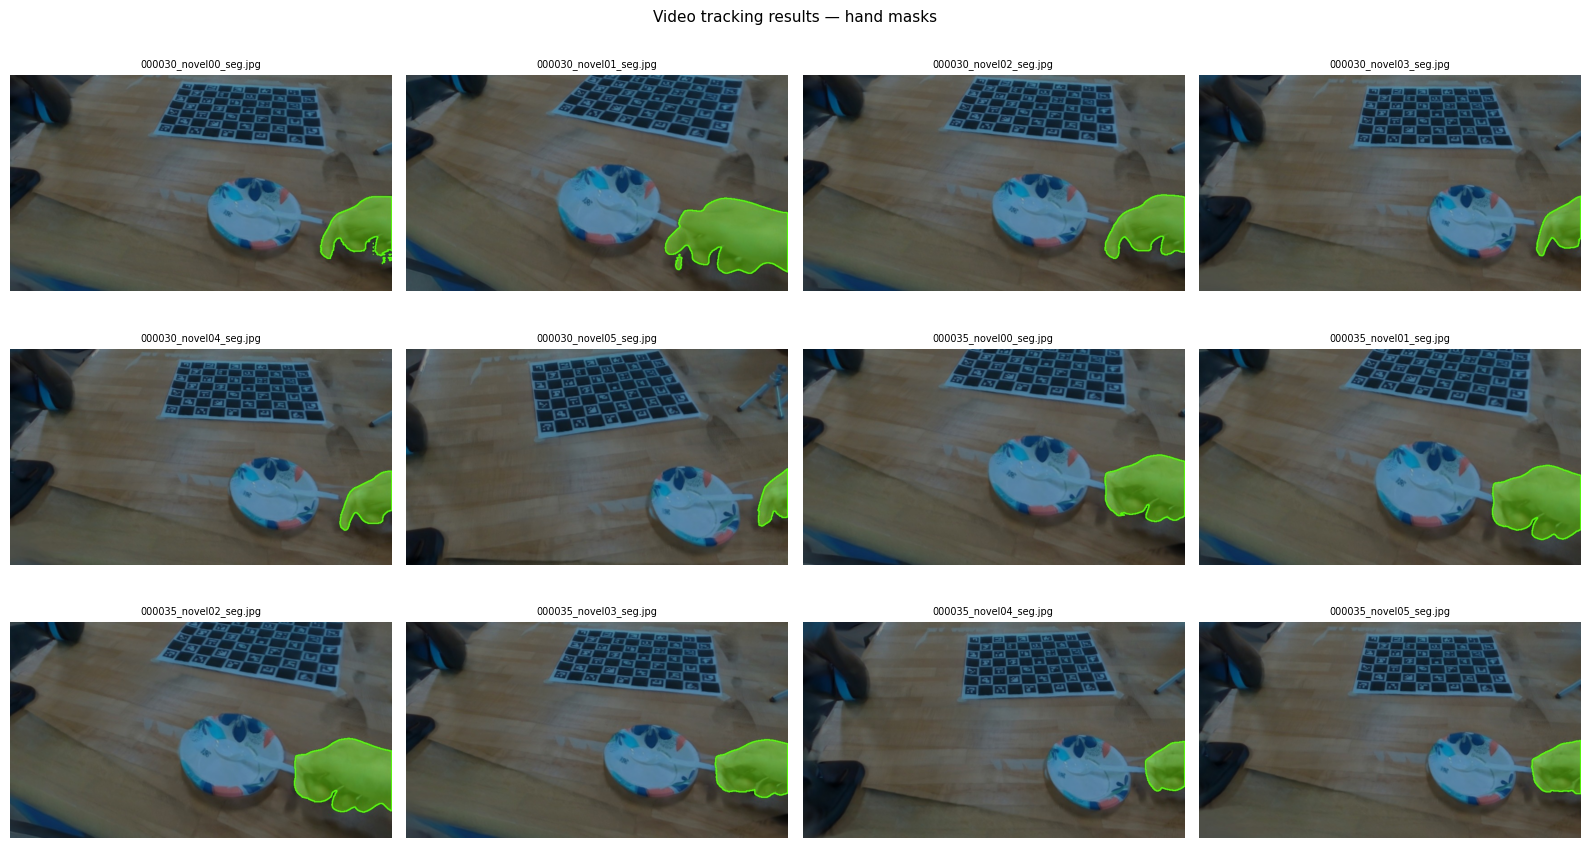

In [54]:
viz_files = sorted(glob.glob(os.path.join(VIZ_DIR, "*.jpg")))

# Only show frames where the mask is non-empty
with_hands = [
    v for v in viz_files
    if frame_masks.get(
        next((k for k,s in idx_to_stem.items()
              if s == os.path.basename(v).replace("_seg.jpg","")), -1),
        np.zeros((1,1), bool)
    ).any()
][:12]

show = with_hands or viz_files[:12]
nc = 4
nr = (len(show) + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(4*nc, 3*nr))
axes = np.array(axes).flatten()
for ax, p in zip(axes, show):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(os.path.basename(p)[-22:], fontsize=7)
    ax.axis("off")
for ax in axes[len(show):]:
    ax.axis("off")
plt.suptitle("Video tracking results — hand masks", fontsize=11)
plt.tight_layout()
plt.show()

## 12 — Save Results to Drive

In [55]:
# Option A — copy straight to Google Drive (recommended)
import shutil
drive_out = "/content/drive/MyDrive/seg4_results_video"
if os.path.exists(drive_out):
    shutil.rmtree(drive_out)
shutil.copytree(OUTPUT_FOLDER, drive_out)
print(f"✅ Saved to Drive: {drive_out}")

# Option B — download as zip (uncomment if you prefer)
# from google.colab import files
# shutil.make_archive("/content/seg_results_video", "zip", OUTPUT_FOLDER)
# files.download("/content/seg_results_video.zip")

✅ Saved to Drive: /content/drive/MyDrive/seg4_results_video
